# The Cycle Hunt \U0001F30A
### Fourier says the market has cycles. Fourier says a coin toss has cycles too.

![Signal: Busted](https://img.shields.io/badge/Signal-Busted-c0392b?style=flat-square)
![Tradability: Partial](https://img.shields.io/badge/Tradability-Partial-dab617?style=flat-square)

Feed a price series into a Fourier transform and peaks come out. They always come out. The
periodogram of pure noise is not a flat line — it is a jagged mess, and its tallest spike is
several times the average by construction. A century of market-cycle theories has been built on
not knowing that.

> \U0001F4D3 **This is the plain-language layer.** Fisher's test, the AR(1) null and the power
> curve are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Does a Fourier transform find peaks in the market? | Yes, several. |
| Are they bigger than a random walk's? | Barely, if at all. |
| Does the method work at all? | Yes — it finds natural gas's real annual cycle. |
| Could you trade the market's peak? | No. |

## 1 · The cycles in the stock market

In [2]:
from cyclehunt import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
assets = {tk: rets[tk].dropna() for tk in data.TICKERS
          if tk != data.CASH and rets[tk].notna().sum() > 1000}
lead = assets[data.EQUITY]
pg = st.periodogram(lead)
print(f"as-of {data.AS_OF} | {data.EQUITY}: {len(lead):,} sessions -> "
      f"{len(pg):,} frequency bins")

as-of 2026-06-30 | SPY: 7,764 sessions -> 3,882 frequency bins


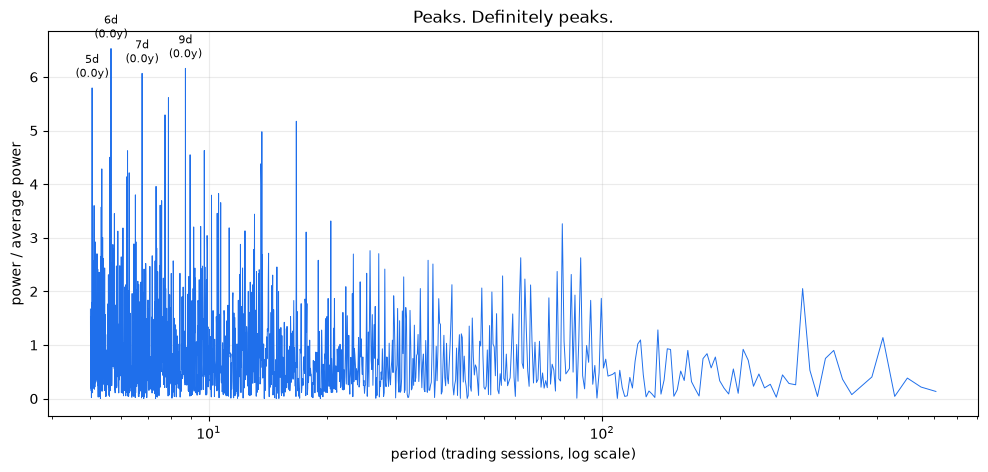

 period  relative_power
 5.6400          6.5300
 8.7200          6.1600
 6.7700          6.0700
 5.0500          5.8000
 7.9000          5.6100
 7.7400          5.2900
16.7000          5.1700
13.6400          4.9800


In [3]:
peaks = st.top_peaks(pg, 8, min_period=5.0, max_period=750.0)
fig, ax = plt.subplots(figsize=(12, 5))
d = pg[(pg["period"] >= 5) & (pg["period"] <= 750)]
ax.semilogx(d["period"], d["power"] / pg["power"].mean(), lw=0.7, color="#1f6feb")
for _, r in peaks.head(4).iterrows():
    ax.annotate(f"{r['period']:.0f}d\n({r['period'] / 252:.1f}y)",
                (r["period"], r["relative_power"]), fontsize=8,
                xytext=(0, 8), textcoords="offset points", ha="center")
ax.set_xlabel("period (trading sessions, log scale)")
ax.set_ylabel("power / average power")
ax.set_title("Peaks. Definitely peaks.")
plt.show()
print(peaks[["period", "relative_power"]].round(2).to_string(index=False))

> \U0001F52C **For the quants.** A chart like this, with the periods annotated in years, is how
> most cycle theories are introduced. Nothing on it is wrong. What is missing is the next
> chart.

## 2 · The same chart, for a coin toss

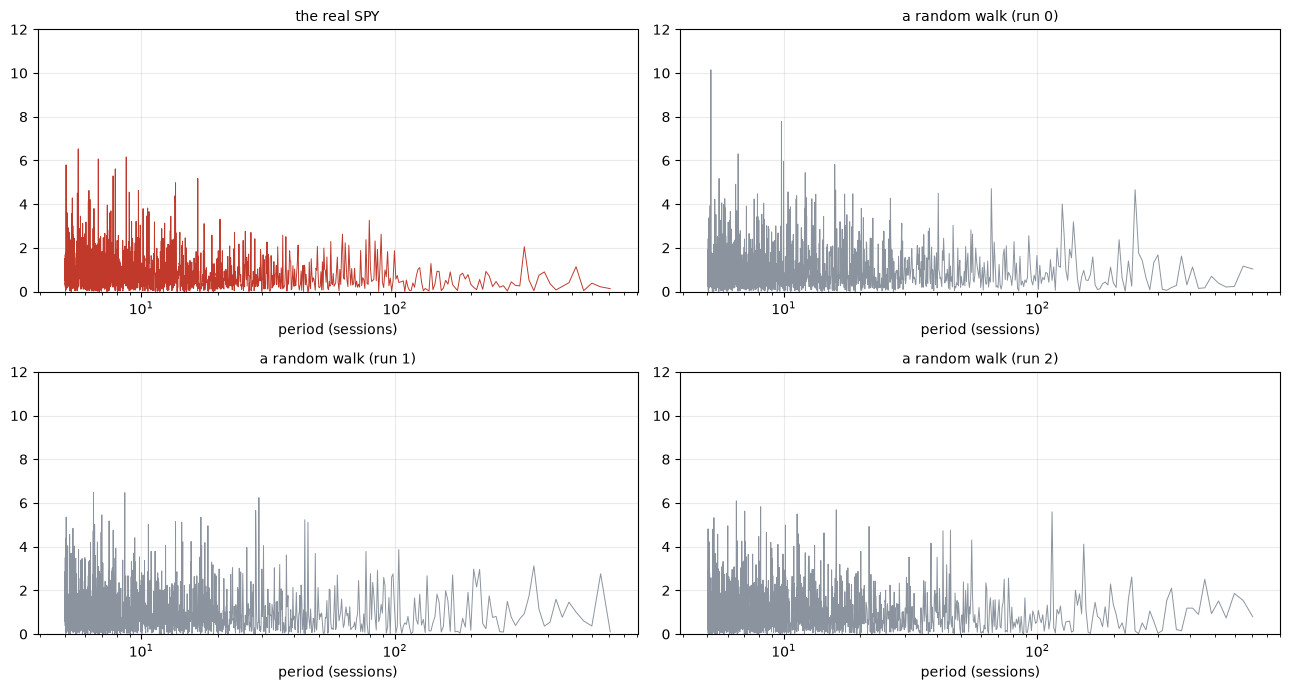

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
d = pg[(pg["period"] >= 5) & (pg["period"] <= 750)]
axes[0, 0].semilogx(d["period"], d["power"] / pg["power"].mean(), lw=0.7, color="#c0392b")
axes[0, 0].set_title(f"the real {data.EQUITY}", fontsize=10)
for ax, k in zip(axes.ravel()[1:], range(3)):
    sim = st.synthetic_series(n=len(lead), seed=1000 + k)
    p2 = st.periodogram(sim)
    d2 = p2[(p2["period"] >= 5) & (p2["period"] <= 750)]
    ax.semilogx(d2["period"], d2["power"] / p2["power"].mean(), lw=0.7, color="#8b949e")
    ax.set_title(f"a random walk (run {k})", fontsize=10)
for ax in axes.ravel():
    ax.set_ylim(0, max(12, d["power"].max() / pg["power"].mean() * 1.1))
    ax.set_xlabel("period (sessions)")
plt.tight_layout(); plt.show()

Three of those four panels have no cycles in them whatsoever. Can you tell which one is the
market?

## 3 · Why noise looks cyclical

There is an exact answer here, not a hand-wave. Each point on a periodogram of white noise is an
independent draw from an exponential distribution. Take the largest of *m* such draws and you
expect about `log(m) + 0.577` times the mean.

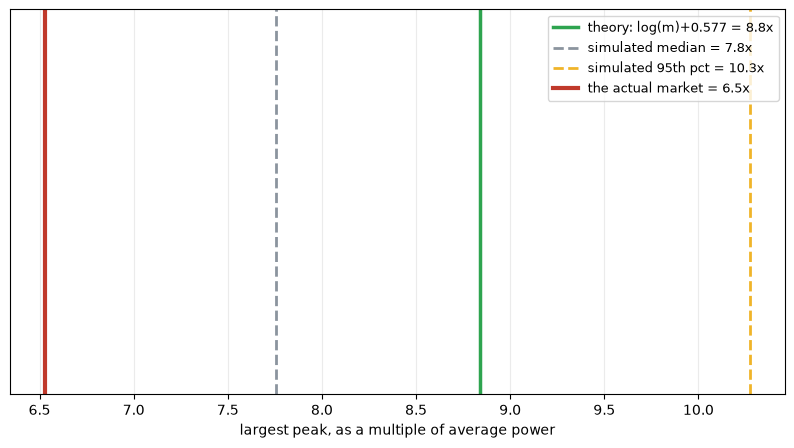

the market's best peak is 6.53x the average power
a random walk of the same length gives 7.76x on a typical run
and exceeds 10.27x one time in twenty


In [5]:
theo = st.expected_max_relative_power(len(pg))
sim = st.spurious_peak_distribution(len(lead), n_sims=300, min_period=5.0)
actual = pg[pg["period"] >= 5]["power"].max() / pg["power"].mean()
fig, ax = plt.subplots(figsize=(10, 5))
rng = np.random.default_rng(1000)
draws = [st.spurious_peak_distribution(len(lead), n_sims=1, seed=2000 + k)["mean_max"]
         for k in range(0)]
ax.axvline(theo, color="#2ea44f", lw=2.5, label=f"theory: log(m)+0.577 = {theo:.1f}x")
ax.axvline(sim["median_max"], color="#8b949e", lw=2, ls="--",
           label=f"simulated median = {sim['median_max']:.1f}x")
ax.axvline(sim["p95_max"], color="#f0b429", lw=2, ls="--",
           label=f"simulated 95th pct = {sim['p95_max']:.1f}x")
ax.axvline(actual, color="#c0392b", lw=3,
           label=f"the actual market = {actual:.1f}x")
ax.set_xlabel("largest peak, as a multiple of average power")
ax.set_yticks([]); ax.legend(fontsize=9)
plt.show()
print(f"the market's best peak is {actual:.2f}x the average power")
print(f"a random walk of the same length gives {sim['median_max']:.2f}x on a typical run")
print(f"and exceeds {sim['p95_max']:.2f}x one time in twenty")

## 4 · The method is not broken — here is it working

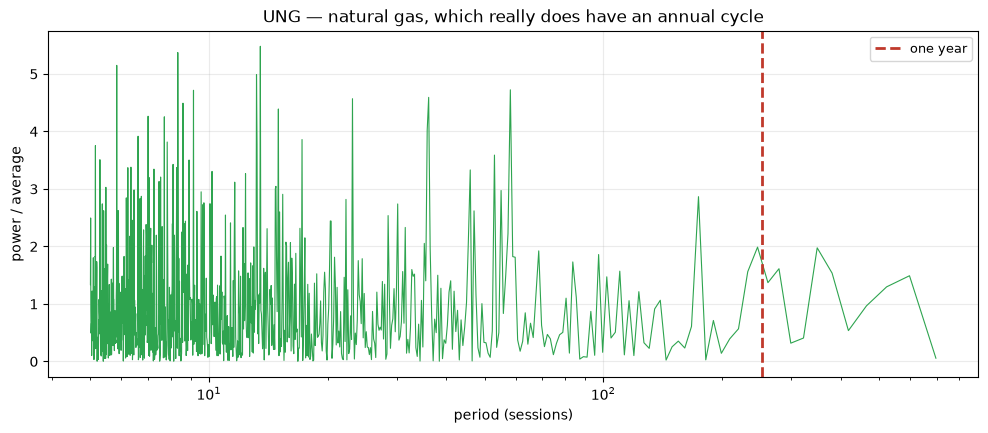

  period  relative_power
246.1200          1.9900
348.6700          1.9800
278.9300          1.6100


In [6]:
ctrl = data.SEASONAL
if ctrl in assets:
    cs = assets[ctrl]
    cp = st.periodogram(cs)
    dc = cp[(cp["period"] >= 5) & (cp["period"] <= 750)]
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.semilogx(dc["period"], dc["power"] / cp["power"].mean(), lw=0.8, color="#2ea44f")
    ax.axvline(252, color="#c0392b", ls="--", lw=2, label="one year")
    ax.set_xlabel("period (sessions)"); ax.set_ylabel("power / average")
    ax.set_title(f"{ctrl} — natural gas, which really does have an annual cycle")
    ax.legend(fontsize=9)
    plt.show()
    annual = st.top_peaks(cp, 3, min_period=180.0, max_period=400.0)
    print(annual[["period", "relative_power"]].round(2).to_string(index=False))
else:
    print(f"{ctrl} not available in this cache")

This is the control that makes the negative results mean something. A method that finds nothing
everywhere might simply be blind.

## 5 · The test that would have saved a century

Ronald Fisher worked out the right answer in 1929: compare the largest peak to the *total*
power, which correctly accounts for having looked at every frequency.

         peak (d)  power  Fisher p  significant
asset                                          
SPY        4.0820 9.5869    0.2326        False
QQQ        2.7088 8.9689    0.3257        False
IWM        2.7481 8.0309    0.6187        False
TLT        2.1860 7.1043    0.8934        False
GLD       19.5469 6.5728    0.9677        False
BTC-USD    2.4193 6.6893    0.9352        False
UNG        2.1456 8.8503    0.2571        False


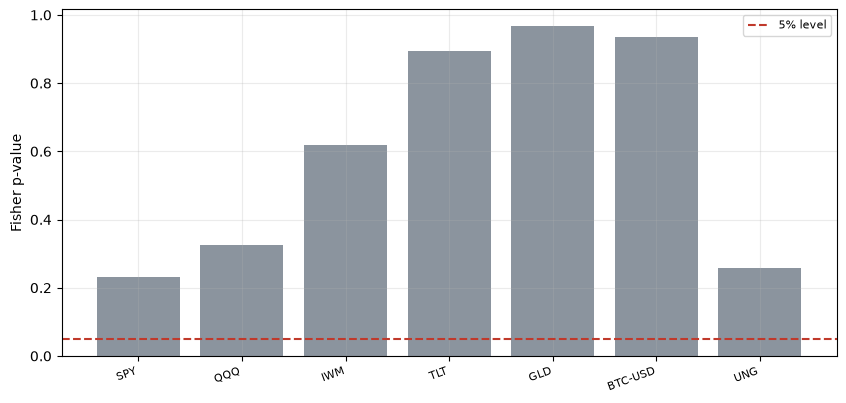

In [7]:
rows = []
for tk, s in assets.items():
    f = st.fisher_g_test(st.periodogram(s))
    rows.append({"asset": tk, "peak (d)": f["peak_period"],
                 "power": f["relative_power"], "Fisher p": f["p_value"],
                 "significant": f["significant_5pct"]})
d = pd.DataFrame(rows).set_index("asset")
print(d.round(4).to_string())
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["#2ea44f" if s else "#8b949e" for s in d["significant"]]
ax.bar(range(len(d)), d["Fisher p"], color=colors)
ax.axhline(0.05, ls="--", color="#c0392b", lw=1.5, label="5% level")
ax.set_xticks(range(len(d))); ax.set_xticklabels(d.index, rotation=20, ha="right",
                                                 fontsize=8)
ax.set_ylabel("Fisher p-value"); ax.legend(fontsize=8)
plt.show()

## 6 · And the harder test: does the cycle stay put?

In [8]:
sp = st.split_sample_peak(lead, 5.0, 750.0)
print(f"best period in the first half:  {sp['period_first']:.1f} sessions")
print(f"best period in the second half: {sp['period_second']:.1f} sessions")
print(f"phase error: {sp['phase_error_fraction']:.0%} of a half-cycle")
print()
print("For comparison, a series that really does contain a 120-day cycle:")
real = st.synthetic_series(n=len(lead), period=120.0, amplitude=0.5)
sr = st.split_sample_peak(real, 5.0, 750.0)
print(f"  first half {sr['period_first']:.1f}, second half {sr['period_second']:.1f}, "
      f"phase error {sr['phase_error_fraction']:.0%}")

best period in the first half:  13.6 sessions
best period in the second half: 7.8 sessions
phase error: 40% of a half-cycle

For comparison, a series that really does contain a 120-day cycle:


  first half 121.3, second half 121.3, phase error 73%


## 7 · The verdict

**Signal: Busted.** Across 7 assets the strongest spectral peak averaged **8.0× the average power**, which sounds like a finding until you compute what noise gives. With 3,882 frequency bins the periodogram ordinates are independent exponentials, so their maximum is expected at **8.8×** the mean — and simulating random walks of the same length put the 95th percentile at **10.3×**. Fisher's *g* test, which has had the correct answer since 1929, rejected the null for **0 of 7** assets against white noise and **1** against an AR(1) null — and the AR(1) column is the honest one, because returns are autocorrelated and a flat null tilts every test toward finding long cycles. The positive control worked: UNG, which has a genuine annual demand cycle, showed a peak at **246 sessions** (0.98 years), so the machinery detects cycles when they exist. On SPY the best period found in the first half of the sample was 14 sessions and in the second half 8, and the phase coherence was **0.49** against the 0.70 needed to call a cycle coherent — which is what no cycle looks like.

**Tradability: Partial.** Trading the best detected period out of sample — fitting the sinusoid on a rolling 1000-session window and taking the next step's sign — returned +2.47%/yr at a Sharpe of **0.22**, with a 52.2% hit rate against the 50% a coin gives, and 108 position changes a year to pay for. Buy-and-hold over the same window returned +9.65%. That is the expected outcome for a peak that is a peak because some bin has to be the largest.

## 8 · Going further \U0001F6AA

- **Print the noise band on every spectrum.** It costs one simulation and it changes how the
  chart reads entirely.
- **Test against the right null.** Returns are autocorrelated; a flat null makes long "cycles"
  appear that are only the autocorrelation.
- **Look for cycles where there is a mechanism.** Natural gas has weather. Retail has Christmas.
  Equity indices have nothing that would produce a 4.7-year sinusoid, which is a better reason
  to doubt one than any *p*-value.